# Experiment: Progressive Signal Isolation
**Question:** Does applying a cropland mask to peak GCVI improve yield prediction R²?

| Condition | GCVI | Regions |
|---|---|---|
| Raw | No mask | Punjab, MP |
| ESA | WorldCover cropland pixels only | Punjab, MP |
| Jordi *(coming)* | Jordi's mask | Punjab, MP |

**Setup:** ERA5 (Jun–Sep) + peak GCVI → Ridge + Random Forest → train 2013–2022, test 2023

In [16]:
import pandas as pd
import numpy as np
import glob, re, os
import rasterio
from rasterstats import zonal_stats
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
import shap

## 1. Config

In [2]:
# TEST_YEAR = 2024

# ── Months to include as features (change this to experiment) ──────────
# 6=Jun, 7=Jul, 8=Aug, 9=Sep, 10=Oct
FEATURE_MONTHS = [7, 8, 9, 10]

REGIONS = {
    'punjab': {
        'shp':        'data/punjab_districts_GAUL/Punjab_Districts_GAUL.shp',
        'era5_csv':   'data/processed/era5_kharif_features_punjab.csv',
        'crop':       'Rice',
        'state_name': 'Punjab',
    },
    'mp': {
        'shp':        'data/mp_districts_GAUL/MP_Districts_GAUL.shp',
        'era5_csv':   'data/processed/era5_kharif_features_mp.csv',
        'crop':       'Rice',
        'state_name': 'Madhya Pradesh',
    },
}

# 'none' = ERA5 only (no GCVI). Add 'jordi' when mask is available.
MASKS = ['none', 'raw', 'esa', 'crop']

NAME_FIXES = {
    # Punjab
    'Ferozepur':             'Firozpur',
    'S.A.S Nagar':           'Sas Nagar (Sahibzada Ajit Singh Nagar)',
    # Madhya Pradesh
    'Narsimhapur':           'Narshimapura',
    'Khargone (West Nimar)': 'West Nimar',
    'Khandwa (East Nimar)':  'East Nimar',
    'Narmadapuram':          'Hoshangabad',
    'Niwari':                'Nivari',
    'Neemuch':               'Nimach',
    'Agar-Malwa':            'Agar Malwa',
}

## 2. Helper functions

## 2b. Sanity checks — run these before the full experiment

In [9]:
# ── 1. TIF files found per region/mask ───────────────────────────────
print("=== TIF file counts ===")
for region in REGIONS:
    for mask in MASKS:
        tifs = sorted(glob.glob(f'data/gcvi/peak_gcvi_kharif_*_{region}_{mask}.tif'))
        years = [int(re.search(r'_(\d{4})_', t).group(1)) for t in tifs]
        print(f"  {region}/{mask}: {len(tifs)} files  years={years}")

=== TIF file counts ===
  punjab/none: 0 files  years=[]
  punjab/raw: 12 files  years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  punjab/esa: 12 files  years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  punjab/crop: 12 files  years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  mp/none: 0 files  years=[]
  mp/raw: 12 files  years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  mp/esa: 12 files  years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  mp/crop: 12 files  years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [10]:
# ── 2. GCVI extraction — spot check punjab/raw ────────────────────────
print("=== GCVI (punjab / raw) ===")
gcvi_check = extract_gcvi('punjab', 'raw')
print(f"Shape: {gcvi_check.shape}")
print(f"Years: {sorted(gcvi_check['year'].unique())}")
print(f"Districts: {gcvi_check['district'].nunique()}")
print(f"NaN count: {gcvi_check['gcvi_mean'].isna().sum()}")
print(f"Value range: {gcvi_check['gcvi_mean'].min():.3f} – {gcvi_check['gcvi_mean'].max():.3f}")
gcvi_check.head(8)

=== GCVI (punjab / raw) ===
  [punjab/raw] Found 12 TIFs
Shape: (264, 3)
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Districts: 22
NaN count: 0
Value range: 2.928 – 5.911


,district,year,gcvi_mean
0,Amritsar,2013,3.542755
1,Barnala,2013,4.919633
2,Bathinda,2013,3.960222
3,Faridkot,2013,4.081113
4,Fatehgarh Sahib,2013,5.098910
5,Fazilka,2013,3.689113
6,Firozpur,2013,4.452790
7,Gurdaspur,2013,3.165090


In [11]:
# ── 3. Compare raw vs ESA GCVI values — should differ if mask is working
print("=== Raw vs ESA GCVI comparison (punjab, 2023) ===")
gcvi_raw = extract_gcvi('punjab', 'raw')
gcvi_esa = extract_gcvi('punjab', 'esa')

merged = gcvi_raw[gcvi_raw['year'] == 2023].merge(
    gcvi_esa[gcvi_esa['year'] == 2023],
    on='district', suffixes=('_raw', '_esa')
)
merged['diff'] = merged['gcvi_mean_esa'] - merged['gcvi_mean_raw']
print(f"Mean difference (ESA - Raw): {merged['diff'].mean():.4f}")
print("If diff ≈ 0 for all rows, raw and ESA masks are identical — indicates a bug in the exports")
merged[['district', 'gcvi_mean_raw', 'gcvi_mean_esa', 'diff']]

=== Raw vs ESA GCVI comparison (punjab, 2023) ===
  [punjab/raw] Found 12 TIFs
  [punjab/esa] Found 12 TIFs
Mean difference (ESA - Raw): 0.1290
If diff ≈ 0 for all rows, raw and ESA masks are identical — indicates a bug in the exports


,district,gcvi_mean_raw,gcvi_mean_esa,diff
0,Amritsar,4.717389,4.913986,0.196597
1,Barnala,5.537263,5.693214,0.155951
2,Bathinda,4.661436,4.854446,0.193009
3,Faridkot,5.010330,5.167785,0.157455
4,Fatehgarh Sahib,5.567374,5.696972,0.129598
5,Fazilka,4.005827,4.111370,0.105543
6,Firozpur,4.875755,4.989982,0.114228
7,Gurdaspur,5.039085,5.172418,0.133332
8,Hoshiarpur,4.727738,4.325692,-0.402046
9,Jalandhar,5.034025,5.276806,0.242781


In [12]:
# ── 4. Mean GCVI across all region / mask combos ─────────────────────
print("=== Mean GCVI by region & mask ===\n")
print(f"{'Region':<10} {'Mask':<6} {'N rows':>7} {'Districts':>10} {'Years':>7} {'NaN':>5} {'Min':>7} {'Mean':>7} {'Max':>7}")
print("-" * 70)

for region in REGIONS:
    for mask in [m for m in MASKS if m != 'none']:
        gcvi = extract_gcvi(region, mask)
        if gcvi.empty:
            print(f"{region:<10} {mask:<6}  -- no data --")
            continue
        print(
            f"{region:<10} {mask:<6} "
            f"{len(gcvi):>7} "
            f"{gcvi['district'].nunique():>10} "
            f"{gcvi['year'].nunique():>7} "
            f"{gcvi['gcvi_mean'].isna().sum():>5} "
            f"{gcvi['gcvi_mean'].min():>7.3f} "
            f"{gcvi['gcvi_mean'].mean():>7.3f} "
            f"{gcvi['gcvi_mean'].max():>7.3f}"
        )

=== Mean GCVI by region & mask ===

Region     Mask    N rows  Districts   Years   NaN     Min    Mean     Max
----------------------------------------------------------------------
  [punjab/raw] Found 12 TIFs
punjab     raw        264         22      12     0   2.928   4.657   5.911
  [punjab/esa] Found 12 TIFs
punjab     esa        264         22      12     0   3.118   4.792   6.078
  [punjab/crop] Found 12 TIFs
punjab     crop       264         22      12     0   3.250   5.005   6.164
  [mp/raw] Found 12 TIFs
mp         raw        636         53      12     0   2.066   3.595   5.464
  [mp/esa] Found 12 TIFs
mp         esa        636         53      12     0   2.009   2.921   4.031
  [mp/crop] Found 12 TIFs
mp         crop       636         53      12     0   0.000   2.725   6.162


In [13]:
# ── 4. ERA5 features ──────────────────────────────────────────────────
print("=== ERA5 features (punjab) ===")
era5_check = load_era5('punjab')
print(f"Shape: {era5_check.shape}")
print(f"Years: {sorted(era5_check['year'].unique())}")
print(f"NaN count: {era5_check.isna().sum().sum()}")
era5_check.head(5)

=== ERA5 features (punjab) ===
Shape: (264, 26)
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
NaN count: 0


,district,year,lai_lv_aug,lai_lv_jul,lai_lv_oct,lai_lv_sep,pev_mm_aug,pev_mm_jul,pev_mm_oct,pev_mm_sep,...,swvl1_oct,swvl1_sep,t2m_c_aug,t2m_c_jul,t2m_c_oct,t2m_c_sep,tp_mm_aug,tp_mm_jul,tp_mm_oct,tp_mm_sep
0,Amritsar,2013,1.922424,1.567261,1.166565,1.602356,-3.604520,-5.356070,-4.038490,-4.648402,...,0.233544,0.257282,29.030664,31.056543,25.212183,28.319971,8.710861,4.320145,0.842094,1.537323
1,Amritsar,2014,1.922424,1.567261,1.166565,1.602356,-5.296431,-5.679466,-4.150514,-4.069932,...,0.216231,0.297941,30.164209,30.925195,24.118188,27.888086,2.862930,6.880760,0.838280,7.599831
2,Amritsar,2015,1.922424,1.567261,1.166565,1.602356,-4.305154,-4.738506,-4.245449,-4.979435,...,0.239233,0.245977,29.767480,30.007227,24.448663,28.395654,5.517006,8.003235,1.326561,2.222061
3,Amritsar,2016,1.922424,1.567261,1.166565,1.602356,-4.491761,-5.120009,-4.865263,-5.200360,...,0.180052,0.220670,29.558740,30.756982,25.795007,29.719385,5.318642,6.074905,0.205994,0.576019
4,Amritsar,2017,1.922424,1.567261,1.166565,1.602356,-4.547395,-5.047880,-4.839454,-5.047228,...,0.178327,0.238568,29.892725,30.615381,25.698816,29.060693,4.303932,6.918907,0.050545,1.037598


In [14]:
# ── 5. Yield data ─────────────────────────────────────────────────────
print("=== Yield data (Punjab / Rice) ===")
yield_check = load_yield('Punjab', 'Rice')
print(f"Shape: {yield_check.shape}")
print(f"Years: {sorted(yield_check['year'].unique())}")
print(f"Districts: {yield_check['district'].nunique()}")
print(f"NaN count: {yield_check.isna().sum().sum()}")
yield_check.head(5)

=== Yield data (Punjab / Rice) ===


Shape: (268, 3)
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Districts: 23
NaN count: 0


,district,yield_kg_ha,year
0,Amritsar,2846.0,2013
1,Barnala,4673.0,2013
2,Bathinda,4514.0,2013
3,Faridkot,4260.0,2013
4,Fatehgarh Sahib,4081.0,2013


In [15]:
# ── 6. Panel after join — check no districts dropped unexpectedly ──────
print("=== Panel after join (punjab / raw) ===")
panel_check = (
    era5_check
    .merge(gcvi_check, on=['district', 'year'], how='inner')
    .merge(yield_check, on=['district', 'year'], how='inner')
    .dropna()
)
print(f"Shape: {panel_check.shape}")
print(f"Years: {sorted(panel_check['year'].unique())}")
print(f"Districts: {panel_check['district'].nunique()}")

# Check for any districts lost in the join
era5_districts   = set(era5_check['district'].unique())
gcvi_districts   = set(gcvi_check['district'].unique())
yield_districts  = set(yield_check['district'].unique())
panel_districts  = set(panel_check['district'].unique())

lost = (era5_districts | gcvi_districts | yield_districts) - panel_districts
if lost:
    print(f"\n⚠️  Districts lost in join: {lost}")
else:
    print("\n✅  No districts lost in join")

panel_check 

=== Panel after join (punjab / raw) ===
Shape: (264, 28)
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Districts: 22

⚠️  Districts lost in join: {'Malerkotla'}


,district,year,lai_lv_aug,lai_lv_jul,lai_lv_oct,lai_lv_sep,pev_mm_aug,pev_mm_jul,pev_mm_oct,pev_mm_sep,...,t2m_c_aug,t2m_c_jul,t2m_c_oct,t2m_c_sep,tp_mm_aug,tp_mm_jul,tp_mm_oct,tp_mm_sep,gcvi_mean,yield_kg_ha
0,Amritsar,2013,1.922424,1.567261,1.166565,1.602356,-3.604520,-5.356070,-4.038490,-4.648402,...,29.030664,31.056543,25.212183,28.319971,8.710861,4.320145,0.842094,1.537323,3.542755,2846.0
1,Amritsar,2014,1.922424,1.567261,1.166565,1.602356,-5.296431,-5.679466,-4.150514,-4.069932,...,30.164209,30.925195,24.118188,27.888086,2.862930,6.880760,0.838280,7.599831,3.455728,2775.0
2,Amritsar,2015,1.922424,1.567261,1.166565,1.602356,-4.305154,-4.738506,-4.245449,-4.979435,...,29.767480,30.007227,24.448663,28.395654,5.517006,8.003235,1.326561,2.222061,3.919798,2834.0
3,Amritsar,2016,1.922424,1.567261,1.166565,1.602356,-4.491761,-5.120009,-4.865263,-5.200360,...,29.558740,30.756982,25.795007,29.719385,5.318642,6.074905,0.205994,0.576019,4.985222,3189.0
4,Amritsar,2017,1.922424,1.567261,1.166565,1.602356,-4.547395,-5.047880,-4.839454,-5.047228,...,29.892725,30.615381,25.698816,29.060693,4.303932,6.918907,0.050545,1.037598,4.377633,3761.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,Tarn Taran,2020,1.945093,1.671460,1.092090,1.529614,-4.353113,-5.962897,-5.228063,-5.366271,...,30.260339,31.034967,24.926416,30.438379,6.012726,5.072021,0.008011,1.594543,5.245890,4111.0
260,Tarn Taran,2021,1.945093,1.671460,1.092090,1.529614,-5.223961,-5.450128,-4.382402,-4.053245,...,30.624017,30.983850,25.382898,28.885889,1.834106,10.519410,3.306961,3.870773,5.372535,3978.0
261,Tarn Taran,2022,1.945093,1.671460,1.092090,1.529614,-4.698633,-4.144729,-4.300341,-4.625057,...,30.470667,29.940332,24.875482,28.979700,2.077866,9.935761,0.235367,4.032135,5.138705,4189.0
262,Tarn Taran,2023,1.945093,1.671460,1.092090,1.529614,-5.377939,-4.528486,-4.214829,-4.850709,...,31.265436,29.945154,24.271082,29.555170,1.459503,7.964325,0.728226,3.369141,4.987467,4247.0


In [7]:
def extract_gcvi(region_key, mask):
    """Extract district-level mean peak GCVI from all TIFs for a region+mask combo.
    Districts with no valid pixels under the mask get gcvi_mean=0 (not dropped).
    """
    cfg = REGIONS[region_key]
    districts = gpd.read_file(cfg['shp']).to_crs('EPSG:4326')
    districts['gaul2_name'] = districts['gaul2_name'].str.strip().str.title()

    pattern = f'data/gcvi/peak_gcvi_kharif_*_{region_key}_{mask}.tif'
    tifs = sorted(glob.glob(pattern))
    print(f"  [{region_key}/{mask}] Found {len(tifs)} TIFs")

    records = []
    for tif in tifs:
        year = int(re.search(r'_(\d{4})_', tif).group(1))

        with rasterio.open(tif) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata
            profile = src.profile

        data[np.isinf(data)] = np.nan
        if nodata is not None:
            data[data == nodata] = np.nan

        import tempfile
        with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
            tmp_path = tmp.name
        profile.update(dtype=rasterio.float32, nodata=np.nan)
        with rasterio.open(tmp_path, 'w', **profile) as dst:
            dst.write(data.astype(np.float32), 1)

        stats = zonal_stats(districts, tmp_path, stats=['mean'], nodata=np.nan)
        os.unlink(tmp_path)

        for i, row in districts.iterrows():
            records.append({
                'district':  row['gaul2_name'],
                'year':      year,
                'gcvi_mean': stats[i]['mean'],
            })

    df = pd.DataFrame(records)
    df['gcvi_mean'] = df['gcvi_mean'].fillna(0)  # districts with no crop pixels → 0
    return df


def load_era5(region_key):
    """Load and pivot ERA5 features to wide format using FEATURE_MONTHS."""
    _month_abbr = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
    MONTH_NAMES = {m: _month_abbr[m - 1] for m in FEATURE_MONTHS}
    ERA5_VARS   = ['tp_mm', 'pev_mm', 't2m_c', 'skt', 'swvl1', 'lai_lv']

    cfg  = REGIONS[region_key]
    era5 = pd.read_csv(cfg['era5_csv'])

    era5 = era5[era5['month'].isin(FEATURE_MONTHS)].copy()
    era5['month_name'] = era5['month'].map(MONTH_NAMES)

    wide = era5.pivot_table(index=['district', 'year'], columns='month_name', values=ERA5_VARS)
    wide.columns = [f'{v}_{m}' for v, m in wide.columns]
    return wide.reset_index()


def load_yield(state_name, crop):
    """Load multi-year DES yield data for a state and crop."""
    des_files = sorted(glob.glob('data/yield/DES-District-Data-For-*-to-*.csv'))
    rows = []
    for path in des_files:
        df = pd.read_csv(path, encoding='utf-8-sig')
        subset = df[(df['State'] == state_name) & (df['Season'] == 'Kharif') & (df['Crop'] == crop)]
        for col in [c for c in df.columns if c.startswith('Yield-')]:
            year = int(re.search(r'Yield-(\d{4})', col).group(1))
            sub = subset[['District', col]].copy()
            sub.columns = ['district', 'yield_kg_ha']
            sub['yield_kg_ha'] = pd.to_numeric(sub['yield_kg_ha'], errors='coerce')
            sub['year'] = year
            rows.append(sub)
    df_out = pd.concat(rows, ignore_index=True).dropna(subset=['yield_kg_ha'])
    df_out['district'] = df_out['district'].str.strip().str.title().replace(NAME_FIXES)
    return df_out


def eval_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    print(f"  {label:35s}  RMSE={rmse:6.0f}  MAE={mae:6.0f}  R²={r2:.3f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


def run_experiment(region_key, mask):
    """Full pipeline for one (region, mask) combination using LOGO-CV by year.
    mask='none' → ERA5 only (no GCVI joined).
    Returns per-fold DataFrames for train/test for both models.
    """
    print(f"\n{'='*60}")
    print(f"  Region: {region_key.upper()}   Mask: {mask.upper()}")
    print(f"{'='*60}")

    era5_df  = load_era5(region_key)
    cfg      = REGIONS[region_key]
    yield_df = load_yield(cfg['state_name'], cfg['crop'])

    if mask == 'none':
        panel = era5_df.merge(yield_df, on=['district', 'year'], how='inner').dropna()
    else:
        gcvi_df = extract_gcvi(region_key, mask)
        panel = (
            era5_df
            .merge(gcvi_df,  on=['district', 'year'], how='inner')
            .merge(yield_df, on=['district', 'year'], how='inner')
            .dropna()
        )

    FEATURE_COLS = [c for c in panel.columns if c not in ('district', 'year', 'yield_kg_ha')]
    groups = panel['year']
    logo   = LeaveOneGroupOut()
    X      = panel[FEATURE_COLS]
    y      = panel['yield_kg_ha']

    # Per-fold lists — local to this call, no accumulation across experiments
    folds_train_ridge, folds_train_rf, folds_train_gbr = [], [], []
    folds_test_ridge,  folds_test_rf, folds_test_gbr  = [], [], []

    for i, (train_idx, test_idx) in enumerate(logo.split(X.values, y.values, groups.values)):
        left_out_year = int(groups.iloc[test_idx[0]])

        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

        ridge = Pipeline([('sc', StandardScaler()),
                          ('m',  RidgeCV(alphas=np.logspace(-2, 4, 50), cv=None))])
        ridge.fit(X_train, y_train)

        rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                                   max_features='sqrt', random_state=42)
        rf.fit(X_train, y_train)

        gbr = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                        learning_rate=0.1, random_state=42)
        gbr.fit(X_train, y_train)

        print(f"\n  ── Fold {i:2d}  (left out: {left_out_year}) ──")
        ridge_tr = eval_metrics(y_train, ridge.predict(X_train), 'Ridge  train')
        rf_tr    = eval_metrics(y_train, rf.predict(X_train),    'RF     train')
        gbr_tr   = eval_metrics(y_train, gbr.predict(X_train),   'GBR    train')
        ridge_te = eval_metrics(y_test,  ridge.predict(X_test),  'Ridge  test ')
        rf_te    = eval_metrics(y_test,  rf.predict(X_test),     'RF     test ')
        gbr_te  = eval_metrics(y_test,  gbr.predict(X_test),    'GBR    test ')

        base = {'region': region_key, 'mask': mask, 'fold': i, 'year': left_out_year}
        folds_train_ridge.append({**base, 'r2': ridge_tr['r2'], 'rmse': ridge_tr['rmse']})
        folds_train_rf.append(   {**base, 'r2': rf_tr['r2'],    'rmse': rf_tr['rmse']})
        folds_train_gbr.append(  {**base, 'r2': gbr_tr['r2'],   'rmse': gbr_tr['rmse']})
        folds_test_ridge.append( {**base, 'r2': ridge_te['r2'], 'rmse': ridge_te['rmse']})
        folds_test_rf.append(    {**base, 'r2': rf_te['r2'],    'rmse': rf_te['rmse']})
        folds_test_gbr.append(   {**base, 'r2': gbr_te['r2'],   'rmse': gbr_te['rmse']})


    ridge_train_df = pd.DataFrame(folds_train_ridge)
    rf_train_df    = pd.DataFrame(folds_train_rf)
    gbr_train_df   = pd.DataFrame(folds_train_gbr)
    ridge_test_df  = pd.DataFrame(folds_test_ridge)
    rf_test_df     = pd.DataFrame(folds_test_rf)
    gbr_test_df    = pd.DataFrame(folds_test_gbr)

    print(f"\n  ── Summary (mean ± std across {len(folds_test_ridge)} folds) ──")
    for label, df in [('Ridge train', ridge_train_df), ('Ridge test', ridge_test_df),
                      ('RF    train', rf_train_df),    ('RF    test', rf_test_df),
                      ('GBR   train', gbr_train_df),   ('GBR   test', gbr_test_df)]:
        print(f"  {label:12s}  R²={df['r2'].mean():.3f} ± {df['r2'].std():.3f}  "
              f"RMSE={df['rmse'].mean():.0f} ± {df['rmse'].std():.0f}")

    return {
        'region':      region_key,
        'mask':        mask,
        'ridge_train': ridge_train_df,
        'ridge_test':  ridge_test_df,
        'rf_train':    rf_train_df,
        'rf_test':     rf_test_df,
        'gbr_train':   gbr_train_df,
        'gbr_test':    gbr_test_df,
    }

## 3. Run all experiments

In [8]:
all_results = []

for region in ['punjab', 'mp']:
    for mask in MASKS:
        result = run_experiment(region, mask)
        all_results.append(result)


  Region: PUNJAB   Mask: NONE

  ── Fold  0  (left out: 2013) ──
  Ridge  train                         RMSE=   333  MAE=   256  R²=0.689
  RF     train                         RMSE=   313  MAE=   250  R²=0.725
  GBR    train                         RMSE=   198  MAE=   153  R²=0.890
  Ridge  test                          RMSE=   341  MAE=   302  R²=0.667
  RF     test                          RMSE=   418  MAE=   336  R²=0.501
  GBR    test                          RMSE=   318  MAE=   241  R²=0.710

  ── Fold  1  (left out: 2014) ──
  Ridge  train                         RMSE=   316  MAE=   240  R²=0.710
  RF     train                         RMSE=   299  MAE=   236  R²=0.740
  GBR    train                         RMSE=   183  MAE=   138  R²=0.902
  Ridge  test                          RMSE=   663  MAE=   527  R²=-0.061
  RF     test                          RMSE=   705  MAE=   563  R²=-0.199
  GBR    test                          RMSE=   676  MAE=   592  R²=-0.104

  ── Fold  2  (left

## 4. Summary comparison table

In [18]:
summary_rows = []
for result in all_results:
    region = result['region']
    mask   = result['mask']
    for label, df in [('Ridge Train', result['ridge_train']), ('Ridge Test', result['ridge_test']),
                      ('RF Train',    result['rf_train']),    ('RF Test',    result['rf_test']),
                      ('GBR Train',   result['gbr_train']),   ('GBR Test',   result['gbr_test'])]:
        summary_rows.append({
            'Region':    region.upper(),
            'Mask':      mask.upper(),
            'Model/Set': label,
            'R² mean':   round(df['r2'].mean(),   3),
            'R² std':    round(df['r2'].std(),    3),
            'RMSE mean': round(df['rmse'].mean(), 0),
            'RMSE std':  round(df['rmse'].std(),  0),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df[summary_df['Model/Set'].isin(['Ridge Test', 'RF Test', 'GBR Test'])]

,Region,Mask,Model/Set,R² mean,R² std,RMSE mean,RMSE std
1,PUNJAB,NONE,Ridge Test,0.245,0.450,458.0,114.0
3,PUNJAB,NONE,RF Test,0.253,0.234,476.0,95.0
5,PUNJAB,NONE,GBR Test,0.302,0.285,454.0,105.0
7,PUNJAB,RAW,Ridge Test,0.400,0.308,411.0,86.0
9,PUNJAB,RAW,RF Test,0.450,0.160,409.0,71.0
11,PUNJAB,RAW,GBR Test,0.565,0.215,356.0,86.0
13,PUNJAB,ESA,Ridge Test,0.431,0.283,402.0,88.0
15,PUNJAB,ESA,RF Test,0.449,0.168,408.0,69.0
17,PUNJAB,ESA,GBR Test,0.526,0.262,369.0,92.0
19,PUNJAB,CROP,Ridge Test,0.405,0.288,412.0,78.0


## 5. R² comparison plot

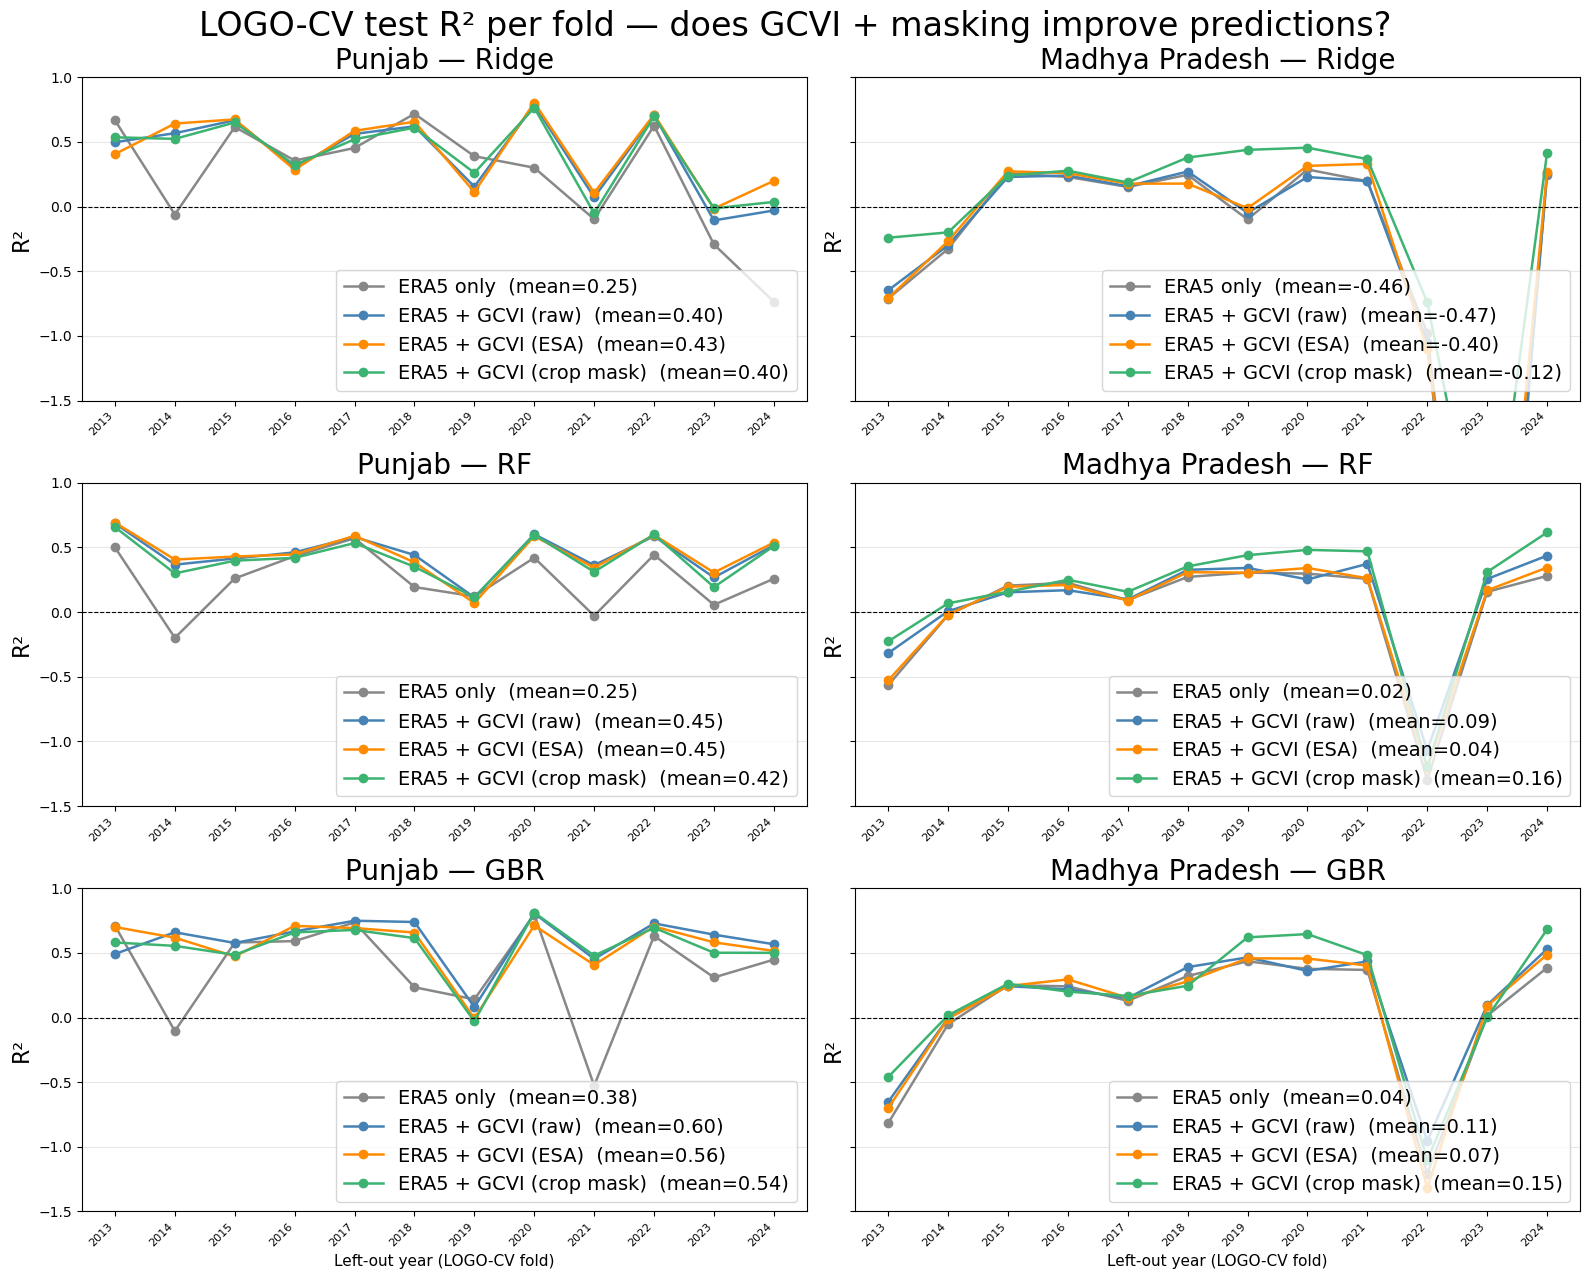

In [9]:
MASK_LABELS = {
    'none': 'ERA5 only',
    'raw':  'ERA5 + GCVI (raw)',
    'esa':  'ERA5 + GCVI (ESA)',
    'crop': 'ERA5 + GCVI (crop mask)',
}
MASK_COLORS = {
    'none': '#888888',
    'raw':  'steelblue',
    'esa':  'darkorange',
    'crop': 'mediumseagreen',
}

# Build a single long-form DataFrame from all results
df_test = pd.concat(
    [pd.concat([r['ridge_test'].assign(model='Ridge'),
                r['rf_test'].assign(model='RF'),
                r['gbr_test'].assign(model='GBR')])
     for r in all_results],
    ignore_index=True
)

regions = [('punjab', 'Punjab'), ('mp', 'Madhya Pradesh')]
models  = ['Ridge', 'RF', 'GBR']

fig, axes = plt.subplots(len(models), len(regions),
                         figsize=(16, 13), sharex=False, sharey=True)

for col, (region_key, region_label) in enumerate(regions):
    reg_df = df_test[df_test['region'] == region_key].copy()
    years  = sorted(reg_df['year'].unique())

    for row, model in enumerate(models):
        ax  = axes[row][col]
        sub = reg_df[reg_df['model'] == model]

        for mask, label in MASK_LABELS.items():
            m_sub = sub[sub['mask'] == mask].sort_values('year')
            if m_sub.empty:
                continue
            mean_r2 = m_sub['r2'].mean()
            ax.plot(m_sub['year'], m_sub['r2'], marker='o', linewidth=1.8,
                    label=f'{label}  (mean={mean_r2:.2f})', color=MASK_COLORS[mask])

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylabel('R²', fontsize=16)
        ax.set_title(f'{region_label} — {model}', fontsize=20)
        ax.legend(loc='lower right', fontsize=14)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(-1.5, 1.0)
        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)

axes[-1][0].set_xlabel('Left-out year (LOGO-CV fold)', fontsize=11)
axes[-1][1].set_xlabel('Left-out year (LOGO-CV fold)', fontsize=11)

plt.suptitle('LOGO-CV test R² per fold — does GCVI + masking improve predictions?', fontsize=24)
plt.tight_layout()
plt.show()


## 6. SHAP Analysis
Trains RF on **all data** (not CV folds) per region × mask condition, then explains predictions with SHAP.

- **Beeswarm**: feature direction and magnitude for each mask
- **Bar chart**: mean |SHAP| comparison across masks — shows whether adding/changing the GCVI mask shifts feature importance

In [20]:
import shap

def compute_shap_rf(region_key, mask):
    """Train RF on all available data for a region+mask and return SHAP values + feature matrix."""
    era5_df  = load_era5(region_key)
    cfg      = REGIONS[region_key]
    yield_df = load_yield(cfg['state_name'], cfg['crop'])

    if mask == 'none':
        panel = era5_df.merge(yield_df, on=['district', 'year'], how='inner').dropna()
    else:
        gcvi_df = extract_gcvi(region_key, mask)
        panel = (
            era5_df
            .merge(gcvi_df,  on=['district', 'year'], how='inner')
            .merge(yield_df, on=['district', 'year'], how='inner')
            .dropna()
        )

    feat_cols = [c for c in panel.columns if c not in ('district', 'year', 'yield_kg_ha')]
    X = panel[feat_cols]
    y = panel['yield_kg_ha']

    rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                               max_features='sqrt', random_state=42)
    rf.fit(X, y)

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X)   # (n_samples, n_features)
    return shap_vals, X


print("Computing SHAP values (RF trained on full data per condition)...")
shap_store = {}
for region in REGIONS:
    for mask in MASKS:
        print(f"  {region} / {mask} ...", end=' ', flush=True)
        sv, Xf = compute_shap_rf(region, mask)
        shap_store[(region, mask)] = {'sv': sv, 'X': Xf}
        print("done")
print("\nAll done.")

Computing SHAP values (RF trained on full data per condition)...
  punjab / none ... done
  punjab / raw ...   [punjab/raw] Found 12 TIFs
done
  punjab / esa ...   [punjab/esa] Found 12 TIFs
done
  punjab / crop ...   [punjab/crop] Found 12 TIFs
done
  mp / none ... done
  mp / raw ...   [mp/raw] Found 12 TIFs
done
  mp / esa ...   [mp/esa] Found 12 TIFs
done
  mp / crop ...   [mp/crop] Found 12 TIFs


KeyboardInterrupt: 

### Beeswarm — feature direction & magnitude per mask

ValueError: Axes has not been added yet

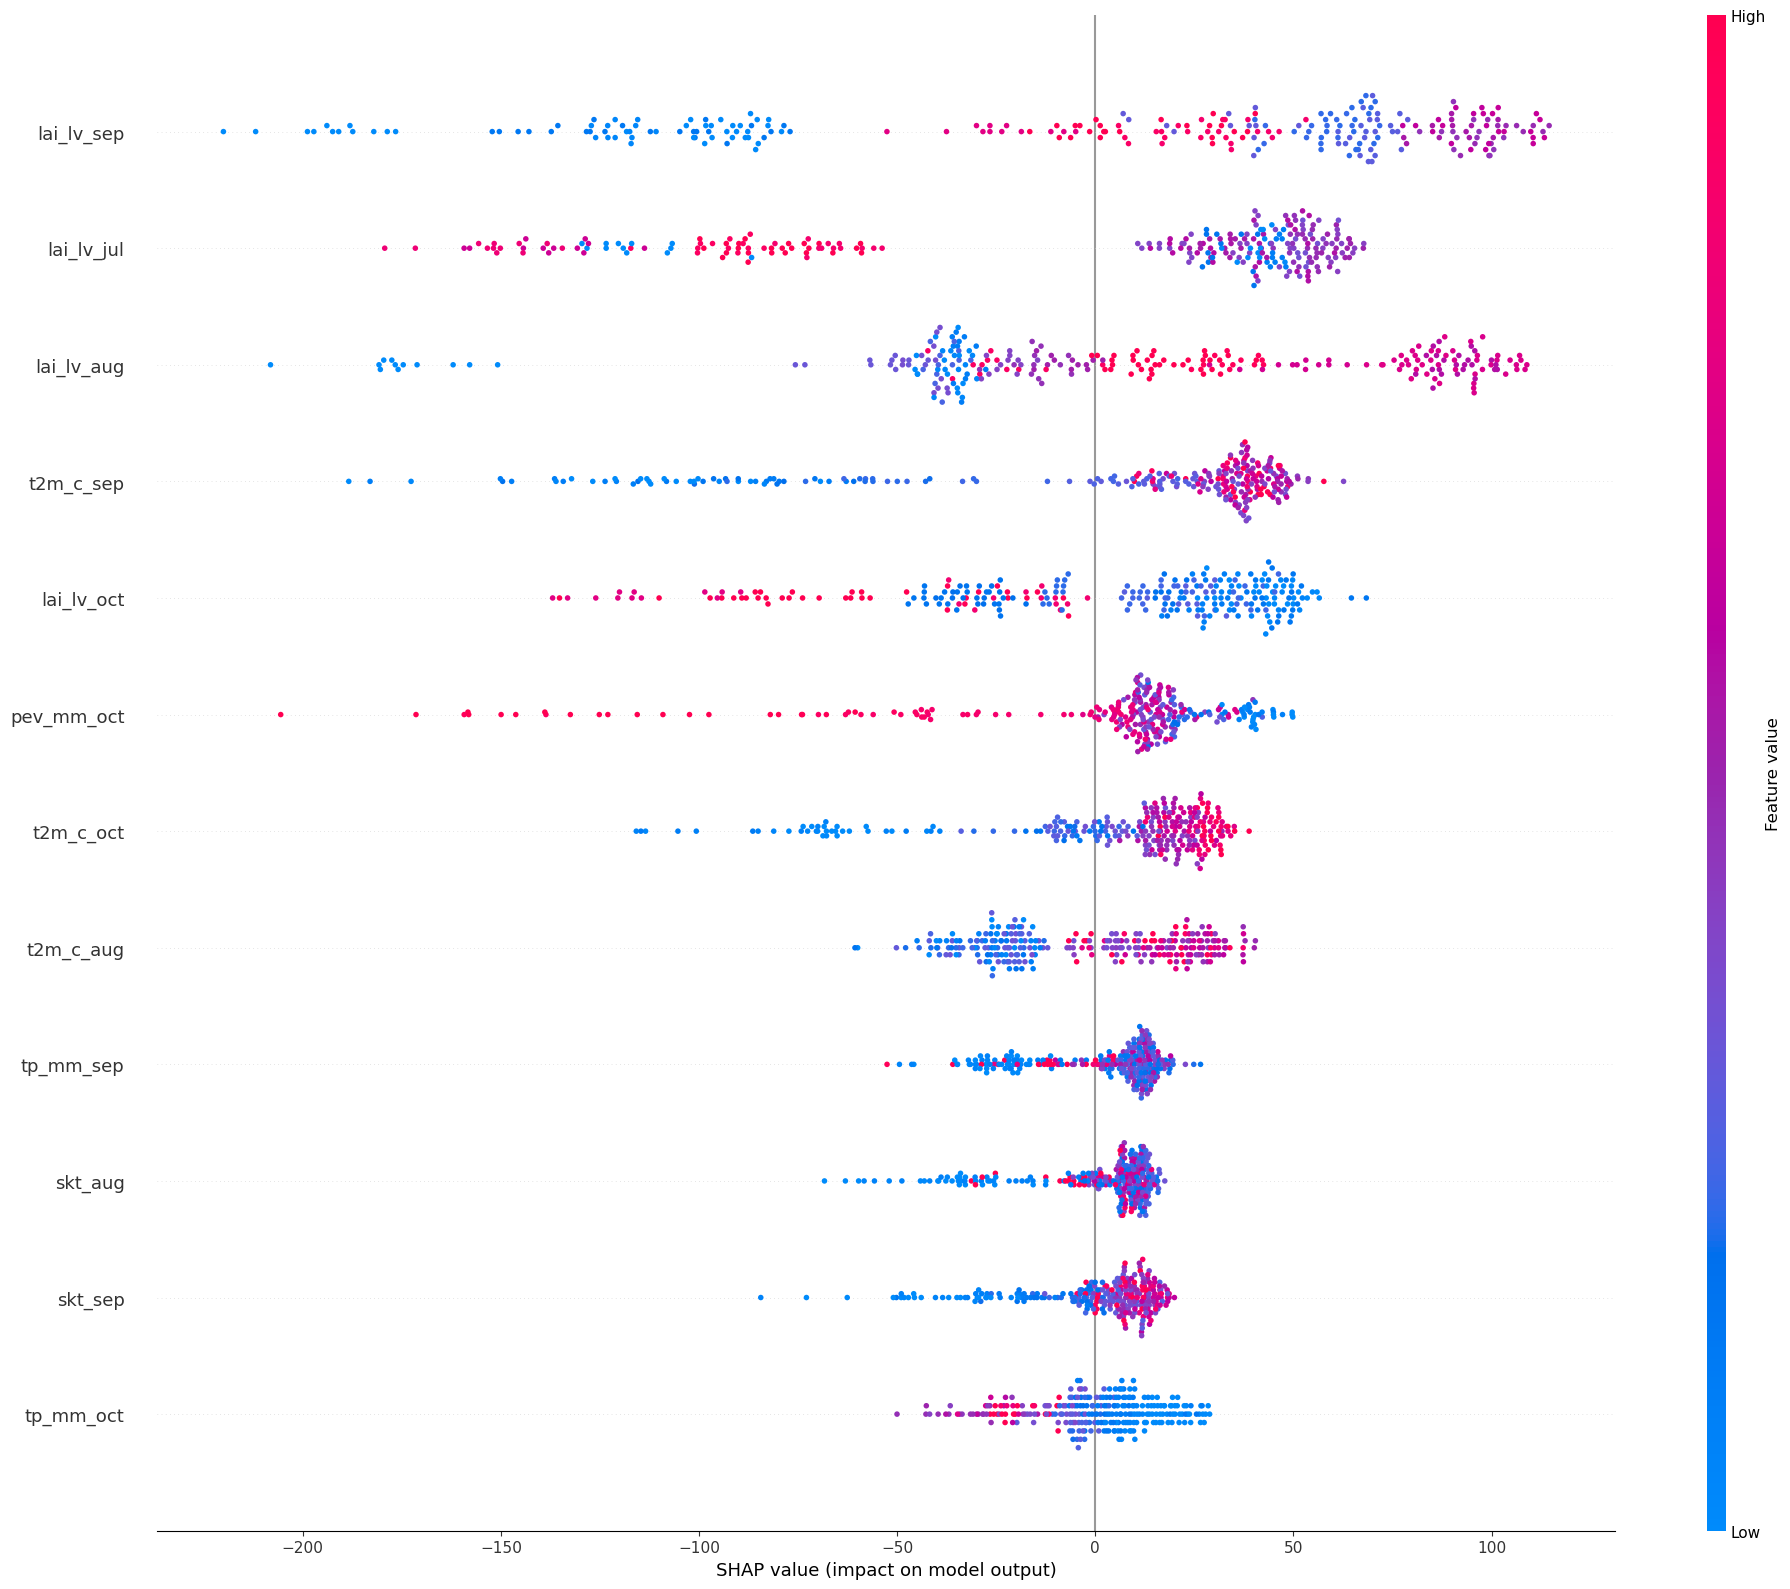

In [ ]:
MAX_DISPLAY = 12

for region_key, region_label in [('punjab', 'Punjab'), ('mp', 'Madhya Pradesh')]:
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'{region_label} — RF SHAP beeswarm by mask condition', fontsize=14)

    for idx, mask in enumerate(MASKS):
        ax = axes[idx // 2][idx % 2]
        sv = shap_store[(region_key, mask)]['sv']
        X  = shap_store[(region_key, mask)]['X']

        plt.figure(fig.number)  # keep our subplot figure active before SHAP draws
        plt.sca(ax)
        shap.summary_plot(sv, X, max_display=MAX_DISPLAY,
                          show=False, plot_size=None)
        ax.set_title(MASK_LABELS[mask], fontsize=11, pad=10)

    plt.tight_layout()
    plt.show()

### Mean |SHAP| — feature importance across masks

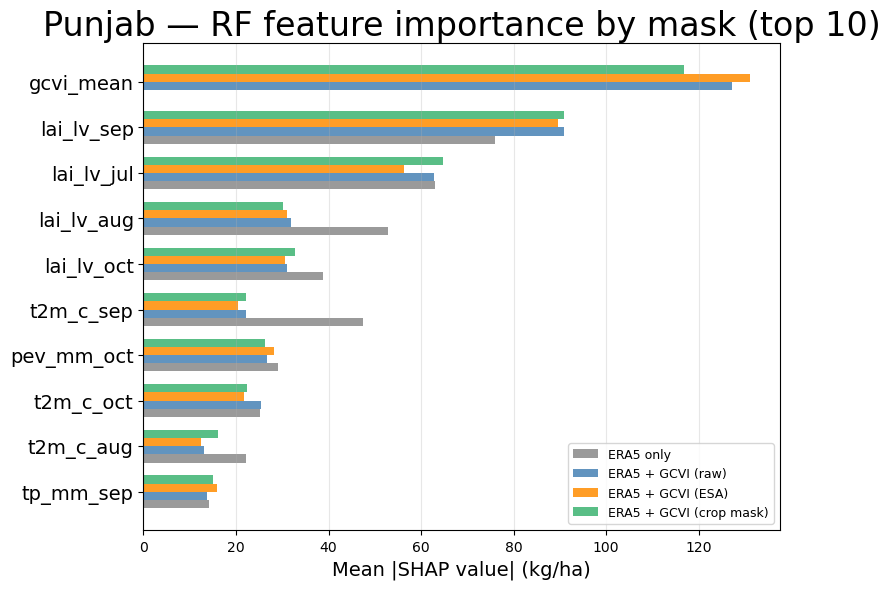

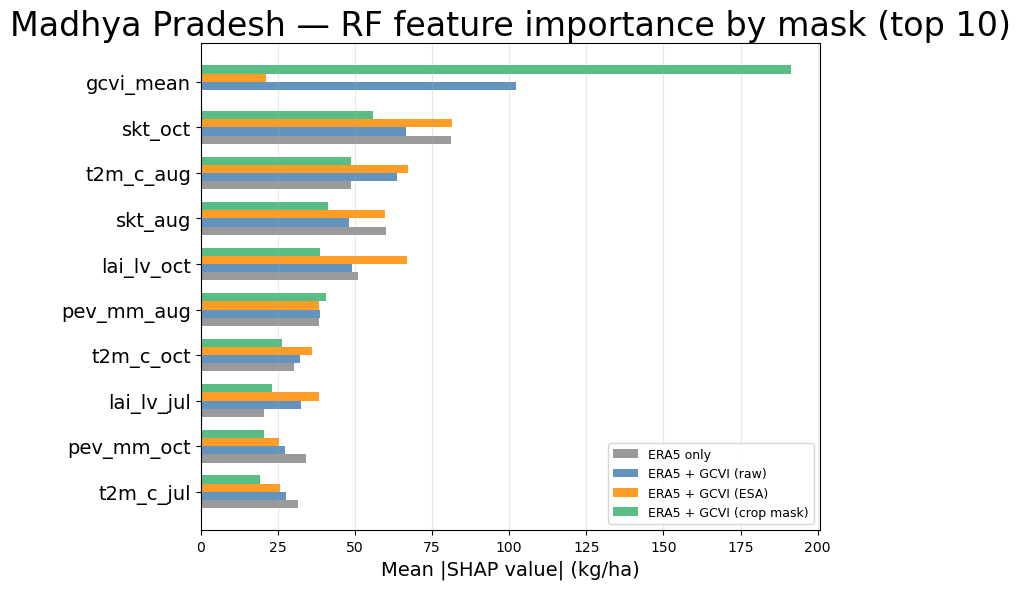

In [ ]:
TOP_N = 10

for region_key, region_label in [('punjab', 'Punjab'), ('mp', 'Madhya Pradesh')]:

    # Build long-form importance table
    records = []
    for mask in MASKS:
        sv = shap_store[(region_key, mask)]['sv']
        X  = shap_store[(region_key, mask)]['X']
        for feat, val in zip(X.columns, np.abs(sv).mean(axis=0)):
            records.append({'feature': feat, 'mask': mask, 'mean_abs_shap': val})
    imp = pd.DataFrame(records)

    # Top N features by mean importance across all masks
    top_feats = (
        imp.groupby('feature')['mean_abs_shap'].mean()
        .nlargest(TOP_N).index.tolist()
    )
    imp_top = imp[imp['feature'].isin(top_feats)]

    # Sort features by overall importance for readability
    feat_order = (
        imp_top.groupby('feature')['mean_abs_shap'].mean()
        .sort_values(ascending=True).index.tolist()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    bar_height = 0.18
    y = np.arange(len(feat_order))

    for i, mask in enumerate(MASKS):
        mask_imp = imp_top[imp_top['mask'] == mask].set_index('feature')
        vals = [mask_imp.loc[f, 'mean_abs_shap'] if f in mask_imp.index else 0
                for f in feat_order]
        ax.barh(y + i * bar_height, vals, bar_height,
                label=MASK_LABELS[mask], color=MASK_COLORS[mask], alpha=0.85)

    ax.set_yticks(y + bar_height * 1.5)
    ax.set_yticklabels(feat_order, fontsize=14)
    ax.set_xlabel('Mean |SHAP value| (kg/ha)', fontsize=14)
    ax.set_title(f'{region_label} — RF feature importance by mask (top {TOP_N})', fontsize=24)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Madhya Pradesh — Sensitivity Analysis (Excluding 2022–23)

The 2022–23 season shows anomalously high reported yield in MP. This section reruns the full experiment pipeline for MP only with that year dropped from LOGO-CV, to check whether the anomaly was distorting the baseline results.

In [12]:
EXCLUDE_YEARS = [2022]   # corresponds to the 2022-23 season label in the DES data

def run_experiment_excl(region_key, mask, exclude_years=EXCLUDE_YEARS):
    """Same as run_experiment but drops specified years before LOGO-CV."""
    print(f"\n{'='*60}")
    print(f"  Region: {region_key.upper()}   Mask: {mask.upper()}   "
          f"Excluding years: {exclude_years}")
    print(f"{'='*60}")

    era5_df  = load_era5(region_key)
    cfg      = REGIONS[region_key]
    yield_df = load_yield(cfg['state_name'], cfg['crop'])

    if mask == 'none':
        panel = era5_df.merge(yield_df, on=['district', 'year'], how='inner').dropna()
    else:
        gcvi_df = extract_gcvi(region_key, mask)
        panel = (
            era5_df
            .merge(gcvi_df,  on=['district', 'year'], how='inner')
            .merge(yield_df, on=['district', 'year'], how='inner')
            .dropna()
        )

    panel = panel[~panel['year'].isin(exclude_years)].copy()
    print(f"  Panel after exclusion: {len(panel)} rows, "
          f"years={sorted(panel['year'].unique())}")

    FEATURE_COLS = [c for c in panel.columns if c not in ('district', 'year', 'yield_kg_ha')]
    groups = panel['year']
    logo   = LeaveOneGroupOut()
    X      = panel[FEATURE_COLS]
    y      = panel['yield_kg_ha']

    folds_train_ridge, folds_train_rf, folds_train_gbr = [], [], []
    folds_test_ridge,  folds_test_rf,  folds_test_gbr  = [], [], []

    for i, (train_idx, test_idx) in enumerate(logo.split(X.values, y.values, groups.values)):
        left_out_year = int(groups.iloc[test_idx[0]])
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

        ridge = Pipeline([('sc', StandardScaler()),
                          ('m',  RidgeCV(alphas=np.logspace(-2, 4, 50), cv=None))])
        ridge.fit(X_train, y_train)

        rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                                   max_features='sqrt', random_state=42)
        rf.fit(X_train, y_train)

        gbr = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                        learning_rate=0.1, random_state=42)
        gbr.fit(X_train, y_train)

        print(f"\n  ── Fold {i:2d}  (left out: {left_out_year}) ──")
        ridge_tr = eval_metrics(y_train, ridge.predict(X_train), 'Ridge  train')
        rf_tr    = eval_metrics(y_train, rf.predict(X_train),    'RF     train')
        gbr_tr   = eval_metrics(y_train, gbr.predict(X_train),   'GBR    train')
        ridge_te = eval_metrics(y_test,  ridge.predict(X_test),  'Ridge  test ')
        rf_te    = eval_metrics(y_test,  rf.predict(X_test),     'RF     test ')
        gbr_te   = eval_metrics(y_test,  gbr.predict(X_test),    'GBR    test ')

        base = {'region': region_key, 'mask': mask, 'fold': i, 'year': left_out_year}
        folds_train_ridge.append({**base, 'r2': ridge_tr['r2'], 'rmse': ridge_tr['rmse']})
        folds_train_rf.append(   {**base, 'r2': rf_tr['r2'],    'rmse': rf_tr['rmse']})
        folds_train_gbr.append(  {**base, 'r2': gbr_tr['r2'],   'rmse': gbr_tr['rmse']})
        folds_test_ridge.append( {**base, 'r2': ridge_te['r2'], 'rmse': ridge_te['rmse']})
        folds_test_rf.append(    {**base, 'r2': rf_te['r2'],    'rmse': rf_te['rmse']})
        folds_test_gbr.append(   {**base, 'r2': gbr_te['r2'],   'rmse': gbr_te['rmse']})

    ridge_train_df = pd.DataFrame(folds_train_ridge)
    rf_train_df    = pd.DataFrame(folds_train_rf)
    gbr_train_df   = pd.DataFrame(folds_train_gbr)
    ridge_test_df  = pd.DataFrame(folds_test_ridge)
    rf_test_df     = pd.DataFrame(folds_test_rf)
    gbr_test_df    = pd.DataFrame(folds_test_gbr)

    print(f"\n  ── Summary (mean ± std across {len(folds_test_ridge)} folds) ──")
    for label, df in [('Ridge train', ridge_train_df), ('Ridge test', ridge_test_df),
                      ('RF    train', rf_train_df),    ('RF    test', rf_test_df),
                      ('GBR   train', gbr_train_df),   ('GBR   test', gbr_test_df)]:
        print(f"  {label:12s}  R²={df['r2'].mean():.3f} ± {df['r2'].std():.3f}  "
              f"RMSE={df['rmse'].mean():.0f} ± {df['rmse'].std():.0f}")

    return {
        'region':      region_key,
        'mask':        mask,
        'ridge_train': ridge_train_df,
        'ridge_test':  ridge_test_df,
        'rf_train':    rf_train_df,
        'rf_test':     rf_test_df,
        'gbr_train':   gbr_train_df,
        'gbr_test':    gbr_test_df,
    }


# ── Run MP only ───────────────────────────────────────────────────────
mp_excl_results = []
for mask in MASKS:
    result = run_experiment_excl('mp', mask)
    mp_excl_results.append(result)


  Region: MP   Mask: NONE   Excluding years: [2022]
  Panel after exclusion: 518 rows, years=[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2023, 2024]

  ── Fold  0  (left out: 2013) ──
  Ridge  train                         RMSE=   673  MAE=   525  R²=0.365
  RF     train                         RMSE=   578  MAE=   459  R²=0.532
  GBR    train                         RMSE=   456  MAE=   361  R²=0.709
  Ridge  test                          RMSE=  1040  MAE=   909  R²=-0.398
  RF     test                          RMSE=   895  MAE=   769  R²=-0.034
  GBR    test                          RMSE=  1071  MAE=   918  R²=-0.480

  ── Fold  1  (left out: 2014) ──
  Ridge  train                         RMSE=   686  MAE=   535  R²=0.367
  RF     train                         RMSE=   579  MAE=   459  R²=0.549
  GBR    train                         RMSE=   465  MAE=   364  R²=0.709
  Ridge  test                          RMSE=   788  MAE=   686  R²=-0.022
  RF     test                      

### Summary table & before/after comparison

In [13]:
# ── MP excl-2022 summary ─────────────────────────────────────────────
excl_rows = []
for result in mp_excl_results:
    mask = result['mask']
    for label, df in [('Ridge Test', result['ridge_test']),
                      ('RF Test',    result['rf_test']),
                      ('GBR Test',   result['gbr_test'])]:
        excl_rows.append({
            'Mask':      mask.upper(),
            'Model':     label,
            'R² mean (excl 2022)':   round(df['r2'].mean(),   3),
            'R² std (excl 2022)':    round(df['r2'].std(),    3),
            'RMSE mean (excl 2022)': round(df['rmse'].mean(), 0),
        })
excl_df = pd.DataFrame(excl_rows)

# ── Pull matching baseline (MP) from all_results ─────────────────────
base_rows = []
for result in all_results:
    if result['region'] != 'mp':
        continue
    mask = result['mask']
    for label, df in [('Ridge Test', result['ridge_test']),
                      ('RF Test',    result['rf_test']),
                      ('GBR Test',   result['gbr_test'])]:
        base_rows.append({
            'Mask':                 mask.upper(),
            'Model':                label,
            'R² mean (all yrs)':   round(df['r2'].mean(), 3),
            'R² std (all yrs)':    round(df['r2'].std(),  3),
            'RMSE mean (all yrs)': round(df['rmse'].mean(), 0),
        })
base_df = pd.DataFrame(base_rows)

# ── Merge side-by-side ───────────────────────────────────────────────
comparison = base_df.merge(excl_df, on=['Mask', 'Model'])
comparison['ΔR² (excl–all)'] = (
    comparison['R² mean (excl 2022)'] - comparison['R² mean (all yrs)']
).round(3)
comparison

,Mask,Model,R² mean (all yrs),R² std (all yrs),RMSE mean (all yrs),R² mean (excl 2022),R² std (excl 2022),RMSE mean (excl 2022),ΔR² (excl–all)
0,NONE,Ridge Test,-0.461,1.497,895.0,-0.150,0.806,818.0,0.311
1,NONE,RF Test,0.017,0.479,810.0,0.196,0.167,738.0,0.179
2,NONE,GBR Test,0.037,0.520,795.0,0.214,0.279,725.0,0.177
3,RAW,Ridge Test,-0.475,1.559,895.0,-0.150,0.754,822.0,0.325
4,RAW,RF Test,0.085,0.416,786.0,0.249,0.166,717.0,0.164
5,RAW,GBR Test,0.107,0.458,768.0,0.252,0.239,710.0,0.145
6,ESA,Ridge Test,-0.403,1.382,882.0,-0.044,0.638,791.0,0.359
7,ESA,RF Test,0.039,0.460,801.0,0.250,0.181,714.0,0.211
8,ESA,GBR Test,0.070,0.543,779.0,0.260,0.362,700.0,0.190
9,CROP,Ridge Test,-0.123,0.993,801.0,0.153,0.460,720.0,0.276


### LOGO-CV R² per fold — MP excluding 2022

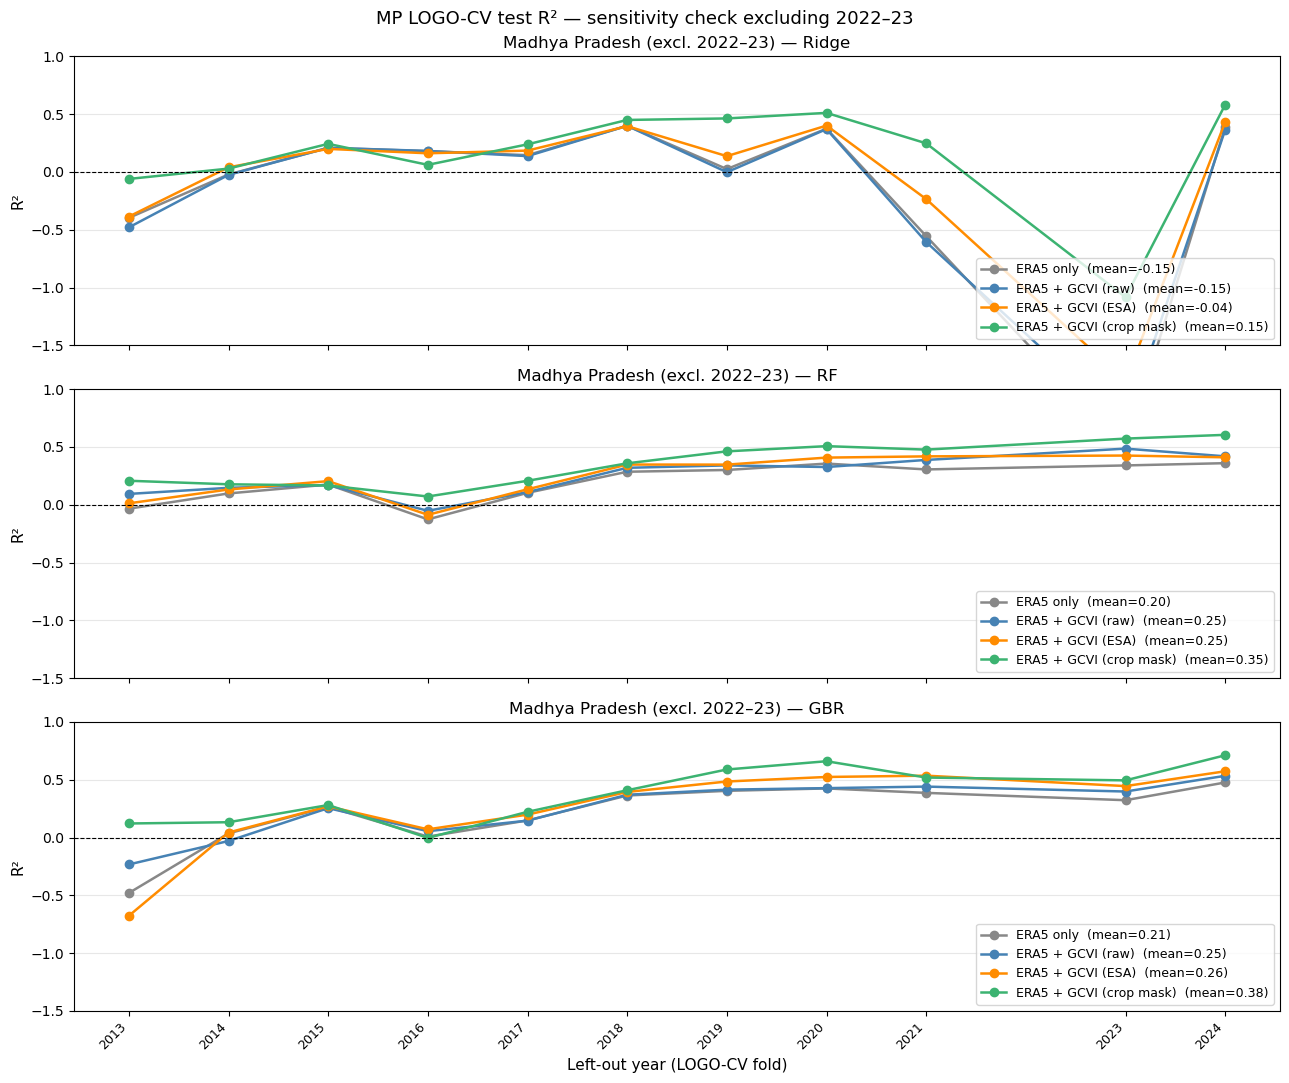

In [14]:
df_excl_test = pd.concat(
    [pd.concat([r['ridge_test'].assign(model='Ridge'),
                r['rf_test'].assign(model='RF'),
                r['gbr_test'].assign(model='GBR')])
     for r in mp_excl_results],
    ignore_index=True
)

models = ['Ridge', 'RF', 'GBR']
fig, axes = plt.subplots(len(models), 1, figsize=(13, 11), sharex=True)

for ax, model in zip(axes, models):
    sub   = df_excl_test[df_excl_test['model'] == model]
    years = sorted(sub['year'].unique())

    for mask, label in MASK_LABELS.items():
        m_sub = sub[sub['mask'] == mask].sort_values('year')
        if m_sub.empty:
            continue
        mean_r2 = m_sub['r2'].mean()
        ax.plot(m_sub['year'], m_sub['r2'], marker='o', linewidth=1.8,
                label=f'{label}  (mean={mean_r2:.2f})', color=MASK_COLORS[mask])

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('R²', fontsize=11)
    ax.set_title(f'Madhya Pradesh (excl. 2022–23) — {model}', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(-1.5, 1.0)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)

axes[-1].set_xlabel('Left-out year (LOGO-CV fold)', fontsize=11)
plt.suptitle('MP LOGO-CV test R² — sensitivity check excluding 2022–23', fontsize=13)
plt.tight_layout()
plt.show()

### SHAP analysis — MP excluding 2022

In [17]:
def compute_shap_excl(region_key, mask, model_type='rf', exclude_years=EXCLUDE_YEARS):
    """Train RF or GBR on data excluding specified years and return SHAP values."""
    era5_df  = load_era5(region_key)
    cfg      = REGIONS[region_key]
    yield_df = load_yield(cfg['state_name'], cfg['crop'])

    if mask == 'none':
        panel = era5_df.merge(yield_df, on=['district', 'year'], how='inner').dropna()
    else:
        gcvi_df = extract_gcvi(region_key, mask)
        panel = (
            era5_df
            .merge(gcvi_df,  on=['district', 'year'], how='inner')
            .merge(yield_df, on=['district', 'year'], how='inner')
            .dropna()
        )

    panel = panel[~panel['year'].isin(exclude_years)].copy()

    feat_cols = [c for c in panel.columns if c not in ('district', 'year', 'yield_kg_ha')]
    X = panel[feat_cols]
    y = panel['yield_kg_ha']

    if model_type == 'rf':
        model = RandomForestRegressor(n_estimators=100, max_depth=5,
                                      max_features='sqrt', random_state=42)
    else:  # gbr
        model = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                          learning_rate=0.1, random_state=42)

    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X)
    return shap_vals, X


print("Computing SHAP values for MP excl. 2022 — RF and GBR...")
shap_store_excl = {}
for model_type in ['rf', 'gbr']:
    for mask in MASKS:
        print(f"  {model_type} / {mask} ...", end=' ', flush=True)
        sv, Xf = compute_shap_excl('mp', mask, model_type=model_type)
        shap_store_excl[(model_type, mask)] = {'sv': sv, 'X': Xf}
        print("done")
print("Done.")

Computing SHAP values for MP excl. 2022 — RF and GBR...
  rf / none ... done
  rf / raw ...   [mp/raw] Found 12 TIFs
done
  rf / esa ...   [mp/esa] Found 12 TIFs
done
  rf / crop ...   [mp/crop] Found 12 TIFs
done
  gbr / none ... done
  gbr / raw ...   [mp/raw] Found 12 TIFs
done
  gbr / esa ...   [mp/esa] Found 12 TIFs
done
  gbr / crop ...   [mp/crop] Found 12 TIFs
done
Done.


ValueError: Axes has not been added yet

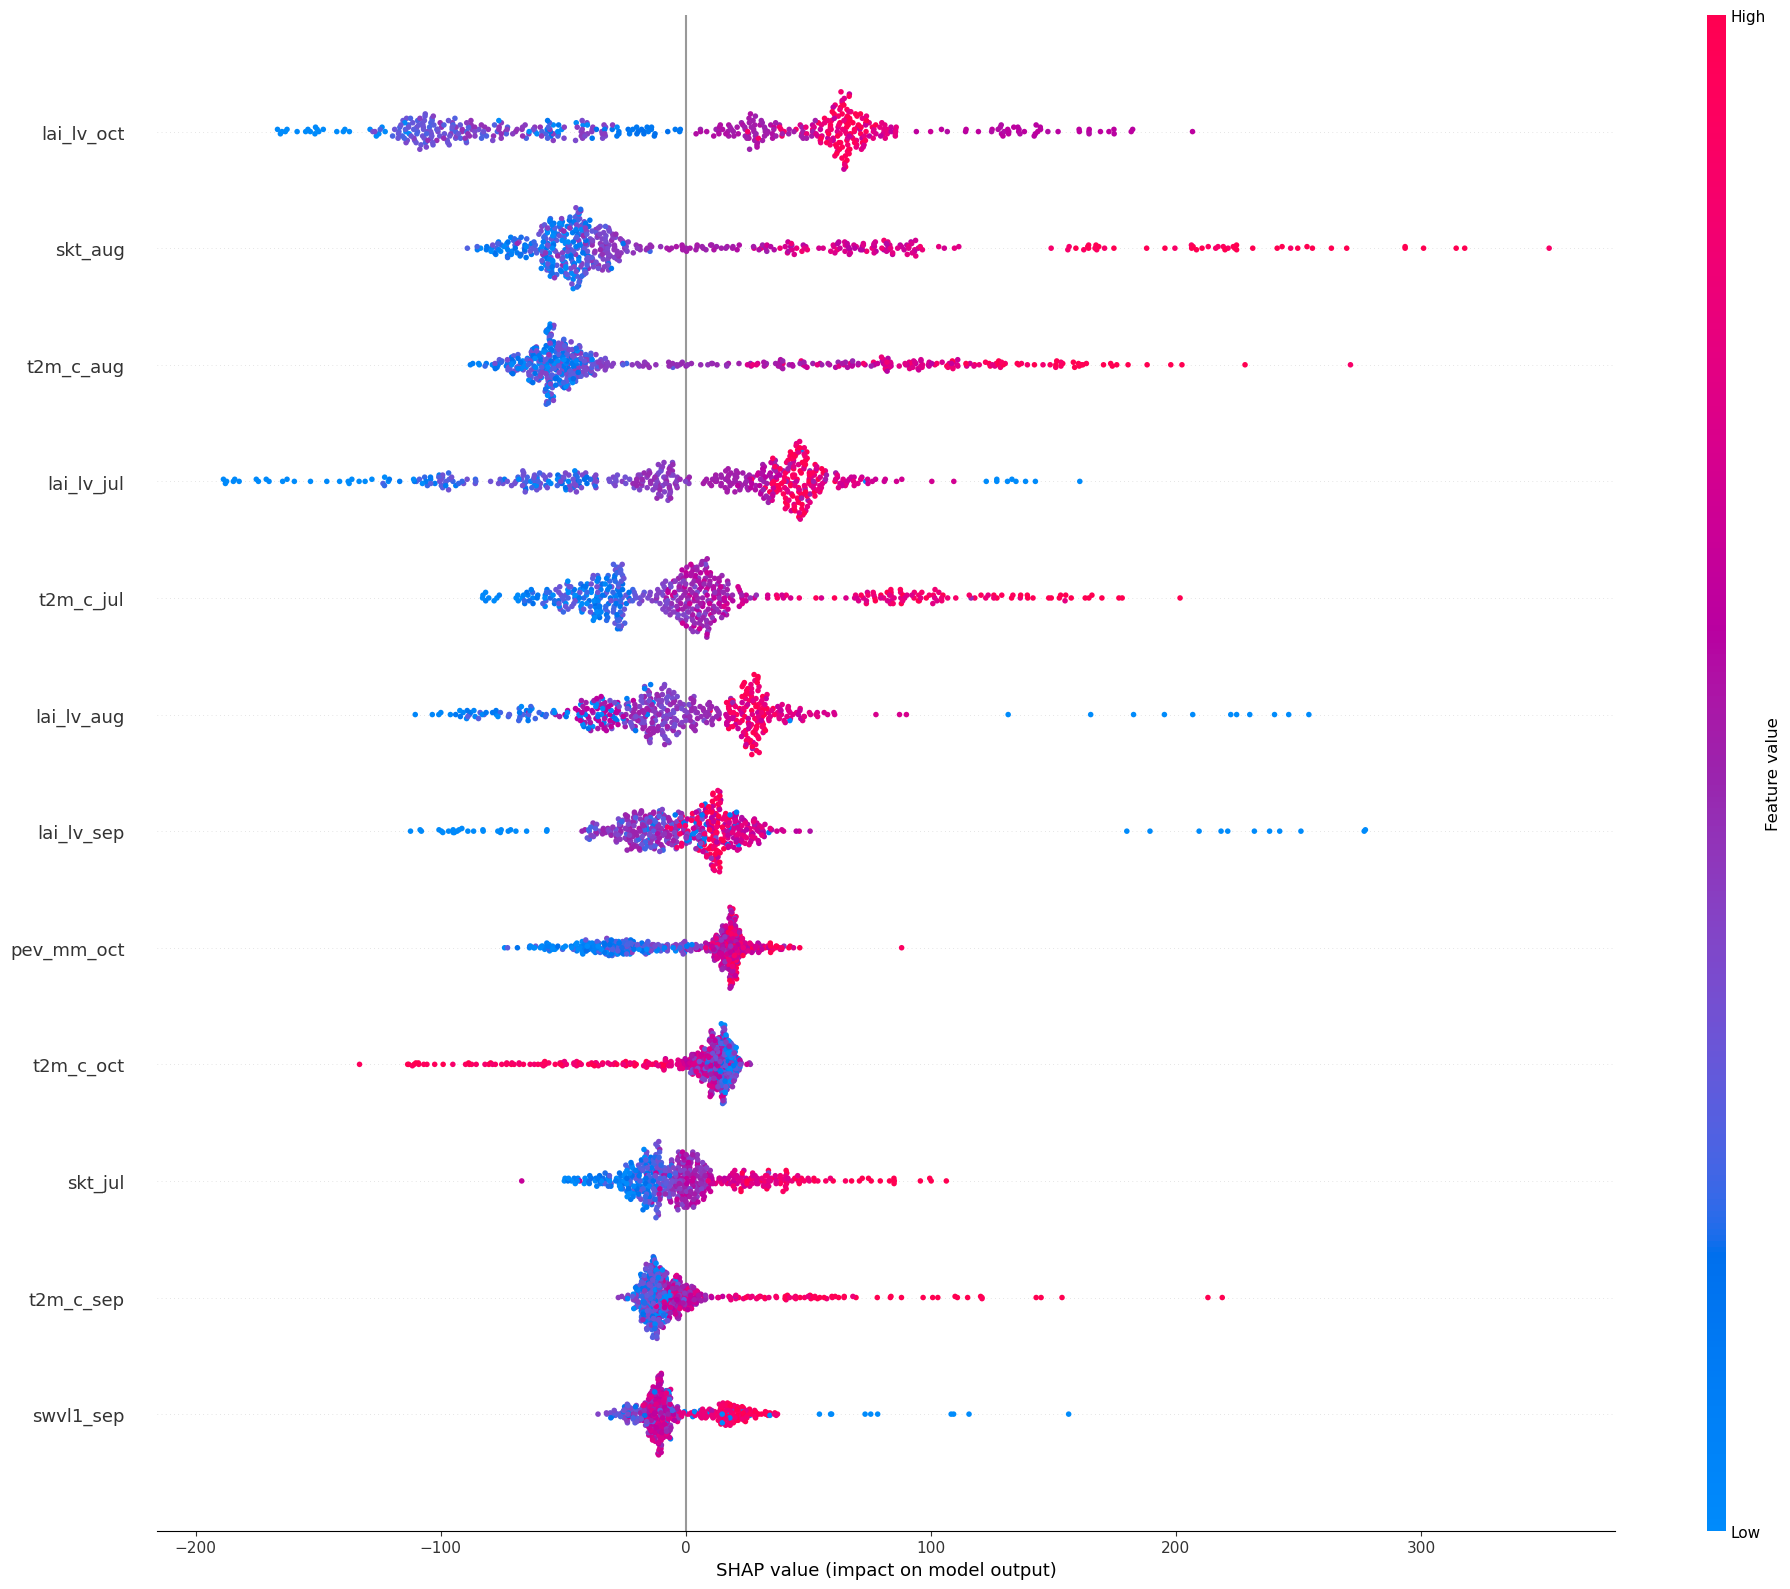

In [18]:
# ── Beeswarm: one 2×2 grid per model (RF then GBR) ───────────────────
MODEL_LABELS = {'rf': 'Random Forest', 'gbr': 'Gradient Boosting'}

for model_type, model_label in MODEL_LABELS.items():
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'MP (excl. 2022–23) — {model_label} SHAP beeswarm by mask', fontsize=14)

    for idx, mask in enumerate(MASKS):
        ax = axes[idx // 2][idx % 2]
        sv = shap_store_excl[(model_type, mask)]['sv']
        X  = shap_store_excl[(model_type, mask)]['X']

        plt.figure(fig.number)
        plt.sca(ax)
        shap.summary_plot(sv, X, max_display=12, show=False, plot_size=None)
        ax.set_title(MASK_LABELS[mask], fontsize=11, pad=10)

    plt.tight_layout()
    plt.show()

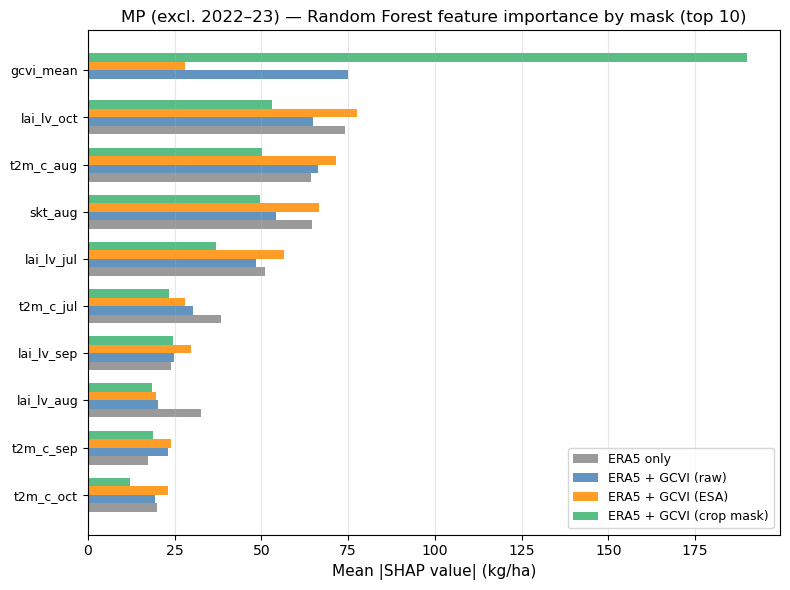

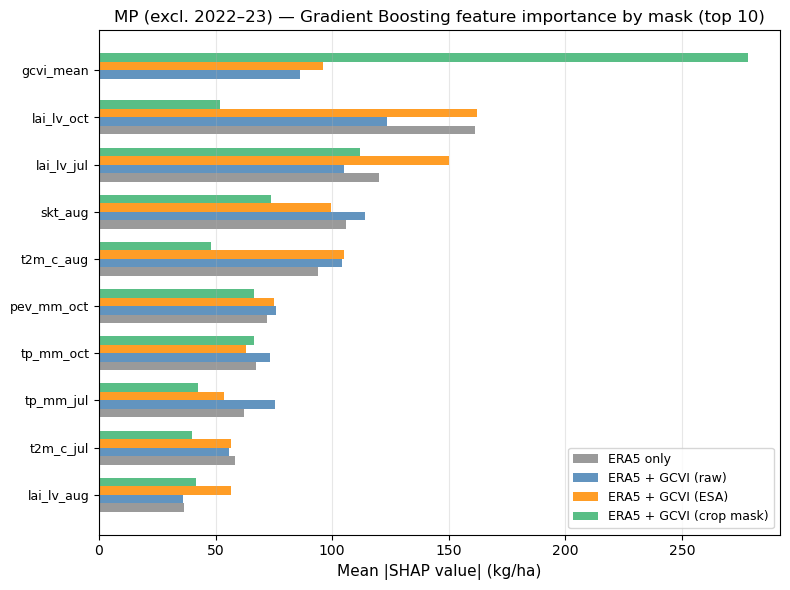

In [19]:
# ── Mean |SHAP| bar chart: RF and GBR side by side per model ─────────
TOP_N = 10

for model_type, model_label in MODEL_LABELS.items():
    records = []
    for mask in MASKS:
        sv = shap_store_excl[(model_type, mask)]['sv']
        X  = shap_store_excl[(model_type, mask)]['X']
        for feat, val in zip(X.columns, np.abs(sv).mean(axis=0)):
            records.append({'feature': feat, 'mask': mask, 'mean_abs_shap': val})
    imp = pd.DataFrame(records)

    top_feats = (
        imp.groupby('feature')['mean_abs_shap'].mean()
        .nlargest(TOP_N).index.tolist()
    )
    imp_top = imp[imp['feature'].isin(top_feats)]
    feat_order = (
        imp_top.groupby('feature')['mean_abs_shap'].mean()
        .sort_values(ascending=True).index.tolist()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    bar_height = 0.18
    y = np.arange(len(feat_order))

    for i, mask in enumerate(MASKS):
        mask_imp = imp_top[imp_top['mask'] == mask].set_index('feature')
        vals = [mask_imp.loc[f, 'mean_abs_shap'] if f in mask_imp.index else 0
                for f in feat_order]
        ax.barh(y + i * bar_height, vals, bar_height,
                label=MASK_LABELS[mask], color=MASK_COLORS[mask], alpha=0.85)

    ax.set_yticks(y + bar_height * 1.5)
    ax.set_yticklabels(feat_order, fontsize=9)
    ax.set_xlabel('Mean |SHAP value| (kg/ha)', fontsize=11)
    ax.set_title(f'MP (excl. 2022–23) — {model_label} feature importance by mask (top {TOP_N})',
                 fontsize=12)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()